<div style="font-family:'Times New Roman';">

En este ejemplo, presentaremos las herramientas de Pyteomics para predecir las características fisicoquímicas básicas de los péptidos, como la masa, la carga y el tiempo de retención cromatográfico. Descargaremos una base de datos FASTA con proteínas de levadura de panadería, la digeriremos con tripsina y estudiaremos las distribuciones de diversas cualidades cuantitativas que pueden medirse en un experimento proteómico típico.

El ejemplo está organizado como un script interrumpido por comentarios. Se asume que el lector ya tiene experiencia con las bibliotecas Numpy y Matplotlib. El código fuente del ejemplo se encuentra aquí here.

Antes de comenzar, necesitamos importar todos los módulos necesarios. Además de Pyteomics, necesitamos las herramientas integradas que permiten acceder al disco duro (SO), descargar archivos de Internet (URL), abrir archivos comprimidos (gzip) y bibliotecas externas para procesar y visualizar matrices de datos (Numpy, Matplotlib).


In [18]:
import os
from urllib.request import urlretrieve
import gzip
import matplotlib.pyplot as plt
import numpy as np
from pyteomics import fasta, parser, mass, achrom, electrochem, auxiliary

<div style="font-family:'Times New Roman';">

También necesitamos descargar una base de datos FASTA real. Para nuestros fines, la base de datos Uniprot con proteínas de Saccharomyces cerevisiae funcionará correctamente. Descargaremos una base de datos comprimida en gzip del servidor FTP de Uniprot:

In [22]:
import os
from urllib.request import urlretrieve
from urllib.error import URLError

if not os.path.isfile('yeast.fasta.gz'):
    print('Downloading the FASTA file for Saccharomyces cerevisiae...')
    url = 'https://ftp.uniprot.org/pub/databases/uniprot/current_release/knowledgebase/reference_proteomes/Eukaryota/UP000002311_559292.fasta.gz'
    try:
        urlretrieve(url, 'yeast.fasta.gz')
        print('Done!')
    except URLError as e:
        print(f'Failed to download from UniProt: {e}')
        # Optionally try an alternative URL
        print('Trying alternative source...')
        alt_url = 'https://rest.uniprot.org/uniprotkb/stream?compressed=true&format=fasta&query=%28proteome%3AUP000002311%29'
        # This URL might work to download all proteins from that proteome
        urlretrieve(alt_url, 'yeast.fasta.gz')
        print('Done!')

Failed to download from UniProt: HTTP Error 404: Not Found
Trying alternative source...
Done!


<div style="font-family:'Times New Roman';">

La pyteomics.fasta.FASTA() clase permite iterar sobre las secuencias de proteínas de un archivo FASTA en un bucle normal de Python. Reemplazó a pyteomics.fasta.read(), aunque este último también sigue existiendo. En este ejemplo, creamos un FASTAobjeto a partir de un objeto similar a un archivo que representa un archivo gzip . Todos los objetos del analizador de archivos son flexibles y admiten diversos casos de uso. Además, pyteomics.fastaadmiten una mayor variedad de tipos y variantes de FASTA.

Para todas las clases de analizadores FASTA, consulte fasta: manipulaciones con bases de datos FASTA . Véase también: explicación de los analizadores indexados .

Para obtener las secuencias de péptidos, cortamos cada proteína usando la pyteomics.parser.cleave()función y combinamos los resultados en un objeto conjunto que descarta automáticamente múltiples ocurrencias de la misma secuencia.

In [23]:
print('Cleaving the proteins with trypsin...')
unique_peptides = set()
with gzip.open('yeast.fasta.gz', mode='rt') as gzfile:
    for description, sequence in fasta.FASTA(gzfile):
        new_peptides = parser.cleave(sequence, 'trypsin')
        unique_peptides.update(new_peptides)
print('Done, {0} sequences obtained!'.format(len(unique_peptides)))

Cleaving the proteins with trypsin...
Done, 188789 sequences obtained!


<div style="font-family:'Times New Roman';">

Más adelante, calcularemos diferentes propiedades de péptidos. Para almacenarlas, creamos una lista de diccionarios, donde cada uno almacena las propiedades de un solo péptido, incluyendo su secuencia.

In [24]:
peptides = [{'sequence': i} for i in unique_peptides]


<div style="font-family:'Times New Roman';">

También es más eficiente analizar previamente las secuencias en aminoácidos individuales y suministrar las estructuras analizadas a las funciones que calculan m/z, carga, etc. Durante el análisis, guardamos explícitamente los grupos terminales de los péptidos para que se tengan en cuenta al calcular m/z y la carga de un péptido.



In [25]:
print('Parsing peptide sequences...')
for peptide in peptides:
    peptide['parsed_sequence'] = parser.parse(
        peptide['sequence'],
        show_unmodified_termini=True)
    peptide['length'] = parser.length(peptide['parsed_sequence'])
print('Done!')

Parsing peptide sequences...
Done!


<div style="font-family:'Times New Roman';">

Para nuestro propósito, nos limitaremos a péptidos razonablemente cortos con una longitud inferior a 100 residuos.

In [26]:
peptides = [peptide for peptide in peptides if peptide['length'] <= 100]


<div style="font-family:'Times New Roman';">

Usamos pyteomics.electrochem.charge()para calcular la carga a pH=2,0. La masa neutra y la relación m/z de un ion se obtienen con pyteomics.mass.calculate_mass().

In [27]:
print('Calculating the mass, charge and m/z...')
for peptide in peptides:
    peptide['charge'] = int(round(
        electrochem.charge(peptide['parsed_sequence'], pH=2.0)))
    peptide['mass'] = mass.calculate_mass(peptide['parsed_sequence'])
    peptide['m/z'] = mass.calculate_mass(peptide['parsed_sequence'],
        charge=peptide['charge'])
print('Done!')

Calculating the mass, charge and m/z...
Done!


<div style="font-family:'Times New Roman';">

A continuación, calculamos el tiempo de retención en la cromatografía de fase inversa y normal utilizando pyteomics.achrom.calculate_RT()dos conjuntos diferentes de coeficientes de retención. La fase se especifica proporcionando los conjuntos correspondientes de coeficientes de retención, pyteomics.achrom.RCs_zubarevy pyteomics.achrom.RCs_yoshida_lcpara las fases inversa y normal, respectivamente.

In [28]:
print('Calculating the retention time...')
for peptide in peptides:
    peptide['RT_RP'] = achrom.calculate_RT(
        peptide['parsed_sequence'],
        achrom.RCs_zubarev)
    peptide['RT_normal'] = achrom.calculate_RT(
        peptide['parsed_sequence'],
        achrom.RCs_yoshida_lc)
print('Done!')

Calculating the retention time...
Done!


<div style="font-family:'Times New Roman';">

Ahora que disponemos de todos los números, podemos estimar la complejidad de una muestra graficando las distribuciones de los parámetros medibles en un experimento proteómico típico. Primero, mostramos la distribución de m/z utilizando la función estándar de histogramas de matplotlib.

Text(0, 0.5, '# of peptides within 2 Th bin')

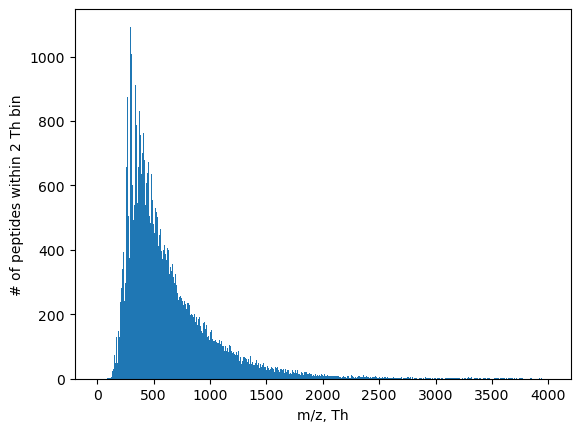

In [29]:
plt.figure()
plt.hist([peptide['m/z'] for peptide in peptides],
    bins = 2000,
    range=(0,4000))
plt.xlabel('m/z, Th')
plt.ylabel('# of peptides within 2 Th bin')

<div style="font-family:'Times New Roman';">

El mismo conjunto de comandos nos permite graficar la distribución de estados de carga en la muestra:



Text(0, 0.5, '# of peptides')

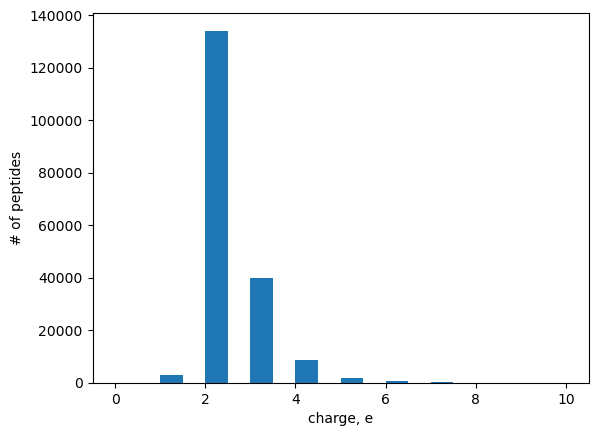

In [30]:
plt.figure()
plt.hist([peptide['charge'] for peptide in peptides],
    bins = 20,
    range=(0,10))
plt.xlabel('charge, e')
plt.ylabel('# of peptides')


<div style="font-family:'Times New Roman';">

A continuación, queremos visualizar la correlación estadística entre m/z y el tiempo de retención en la cromatografía de fase inversa.

El enfoque estándar sería usar un diagrama de dispersión. Sin embargo, con una muestra de nuestro tamaño, esto no sería informativo. En su lugar, trazaremos un histograma 2D. No existe un comando estándar de matplotlib para esto, y debemos usar una combinación de numpy y matplotlib. La función numpy.histogram2d()clasifica un conjunto de puntos (x,y) en un plano y devuelve la matriz de números en cada intervalo individual y sus bordes. También usamos un truco: reemplazar ceros en esta matriz con el valor que no es un número, de modo que en la figura final, los intervalos vacíos se resalten en blanco en lugar del azul más oscuro. Sugerimos eliminar la cuarta línea de este fragmento de código para ver cómo afecta esto al gráfico final. En la última línea, también aplicamos la regresión lineal para obtener el coeficiente de correlación entre m/z y el tiempo de retención.

In [31]:
x = [peptide['RT_RP'] for peptide in peptides]
y = [peptide['RT_normal'] for peptide in peptides]
heatmap, xbins, ybins = np.histogram2d(x, y, bins=100)
heatmap[heatmap == 0] = np.nan
a, b, r, stderr = auxiliary.linear_regression(x,y)

<div style="font-family:'Times New Roman';">

El mapa de calor obtenido se grafica con matplotlib.pyplot.imshow()una función que visualiza matrices.



Text(0.5, 1.0, 'All tryptic peptides, RT correlation = -0.22424042790089593')

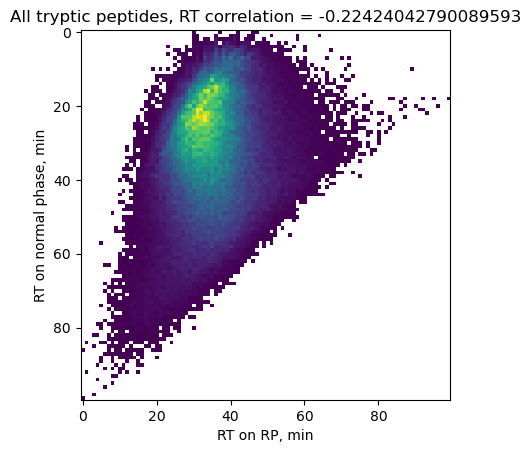

In [32]:
plt.figure()
plt.imshow(heatmap)
plt.xlabel('RT on RP, min')
plt.ylabel('RT on normal phase, min')
plt.title('All tryptic peptides, RT correlation = {0}'.format(r))

<div style="font-family:'Times New Roman';">

El mismo código también puede aplicarse para comparar los tiempos de retención obtenidos en diferentes fases cromatográficas. Como se puede observar al ejecutar el código, los tiempos de retención obtenidos en diferentes fases cromatográficas parecen no estar correlacionados.

Text(0.5, 1.0, 'All tryptic peptides, correlation = 0.6729551027364279')

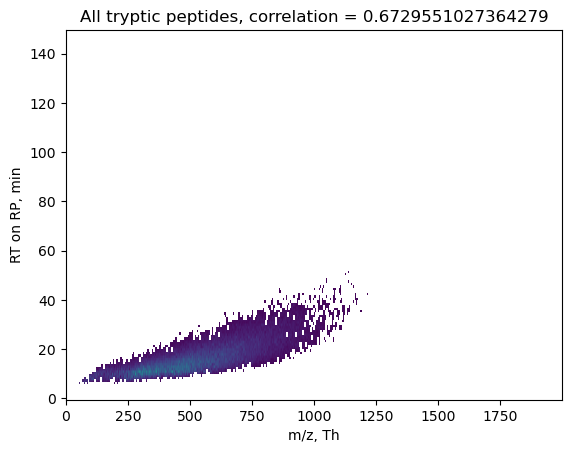

In [33]:
x = [peptide['m/z'] for peptide in peptides]
y = [peptide['RT_RP'] for peptide in peptides]
heatmap, xbins, ybins = np.histogram2d(x, y,
    bins=[150, 2000],
    range=[[0, 4000], [0, 150]])
heatmap[heatmap == 0] = np.nan
a, b, r, stderr = auxiliary.linear_regression(x,y)

plt.figure()
plt.imshow(heatmap,
    aspect='auto',
    origin='lower')
plt.xlabel('m/z, Th')
plt.ylabel('RT on RP, min')
plt.title('All tryptic peptides, correlation = {0}'.format(r))

<div style="font-family:'Times New Roman';">

Finalmente, comprobamos si los tiempos de retención permanecen incorrelados al reducir la muestra de péptidos. Seleccionamos los péptidos con una relación m/z en una ventana de 700-701 Th y graficamos dos tiempos de retención cromatográficos. En esta ocasión, la muestra nos permite utilizar un diagrama de dispersión.

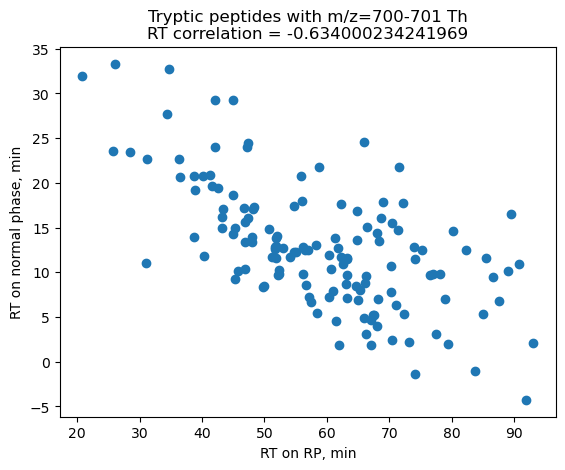

In [34]:
close_mass_peptides = [peptide for peptide in peptides
                       if 700.0 <= peptide['m/z'] <= 701.0]
x = [peptide['RT_RP'] for peptide in close_mass_peptides]
y = [peptide['RT_normal'] for peptide in close_mass_peptides]
a, b, r, stderr = auxiliary.linear_regression(x, y)

plt.figure()
plt.scatter(x, y)
plt.xlabel('RT on RP, min')
plt.ylabel('RT on normal phase, min')
plt.title('Tryptic peptides with m/z=700-701 Th\nRT correlation = {0}'.format(r))

plt.show()

<div style="font-family:'Times New Roman';">

Como se puede ver, los tiempos de retención de los péptidos que se encuentran en una ventana de masa estrecha resultan estar sustancialmente correlacionados.

Llegamos a este punto. El siguiente ejemplo cubrirá los módulos que permiten acceder a conjuntos de datos proteómicos experimentales almacenados en formatos XML.